# 🚀 X/Twitter strategy audit: Minervini SEPA trend template

## 🧭 tl;dr

A popular X post summarized Mark Minervini’s SEPA approach: price above rising moving averages, near a 52-week high, and materially above its 52-week low, alongside fundamental growth and relative-strength filters. This notebook tests the **technical trend-template subset** across liquid ETFs. It cannot test the fundamental, catalyst, sponsorship, or volatility-contraction requirements with the project’s price-only data.

> Educational research only. Not financial advice. This is a technical proxy, not a replication of Minervini’s stock-selection process.

<div style="border-left: 5px solid #EA580C; padding: 0.85em 1em; margin: 1em 0 1.4em; background: #FFF7ED; border-radius: 8px;"><strong>🧑‍🏫 Reader guide</strong><br>The important lesson is the implementation gap: a clean chart rule is testable, but the original method includes information that is not in this dataset.</div>


## 📚 Source and research question

The X post lists the trend-template rules as:

- Price above the 50-, 150-, and 200-day simple moving averages.
- 50-day SMA above 150-day SMA above 200-day SMA.
- 200-day SMA rising for at least one month.
- Price within 25% of its 52-week high.
- Price at least 30% above its 52-week low.
- Additional filters: accelerating EPS/sales, positive surprises, relative-strength rating, institutional sponsorship, catalysts, and volatility-contraction patterns.

Source: [Market Rebellion X post summarizing Minervini’s SEPA](https://x.com/RebellioMarket/status/2018972895304894065).

**Research question:** does the technical template alone create a useful, diversified ETF-rotation signal after monthly rebalancing and costs?


In [1]:

from pathlib import Path
import sys
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    if (ROOT.parent / "src").exists():
        ROOT = ROOT.parent
    elif "__file__" in globals():
        ROOT = Path(__file__).resolve().parents[1]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.backtest import run_backtest, split_time_series
from src.data import load_price_data, load_price_panel, make_demo_ohlcv
from src.portfolio import run_portfolio_backtest
from src.research import metrics_for_period

plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})


In [2]:

def load_sepa_panel():
    tickers = ["SPY", "QQQ", "SMH", "IWM", "XLK", "XLF"]
    try:
        panel = load_price_panel(tickers, "2004-01-01", "2026-01-01")
        source = "Yahoo Finance adjusted daily ETF closes"
    except Exception as exc:
        demo = make_demo_ohlcv(periods=5_500, seed=606, start="2004-01-01")["close"]
        panel = pd.DataFrame({ticker: demo * (1.0 + 0.03 * i) for i, ticker in enumerate(tickers)}, index=demo.index)
        source = f"deterministic demo ETF panel fallback ({type(exc).__name__})"
    return panel.dropna(), source


close, data_source = load_sepa_panel()
print(f"Data source: {data_source}")
print(f"Observations: {len(close):,} | {close.index.min().date()} to {close.index.max().date()}")
display(close.head())


Data source: Yahoo Finance adjusted daily ETF closes
Observations: 5,535 | 2004-01-02 to 2025-12-31


,IWM,QQQ,SMH,SPY,XLF,XLK
Date,,,,,,
2004-01-02,41.701385,30.650198,17.577770,73.644196,14.542001,7.685283
2004-01-05,42.189171,31.265551,18.214647,74.445305,14.661064,7.872915
2004-01-06,42.133331,31.476292,18.320795,74.518097,14.655886,7.944211
2004-01-07,42.580170,31.762890,18.537327,74.769722,14.666242,7.981738
2004-01-08,42.904129,32.015804,19.029846,75.067642,14.718016,8.139345


## 📜 Technical-only proxy rules

At each month start, for every ETF:

1. Compute 50-, 150-, and 200-day SMAs using information available before the decision.
2. Require `price > SMA50 > SMA150 > SMA200`.
3. Require the 200-day SMA to be higher than it was 21 trading days earlier.
4. Require price to be at least 75% of its prior 252-day high and at least 130% of its prior 252-day low.
5. Equal-weight all qualifying ETFs; hold cash if none qualify until the next monthly rebalance.

This is intentionally a **proxy**. It omits fundamentals, relative-strength rankings, institutional sponsorship, catalysts, and VCP pattern recognition.


In [3]:

def sepa_proxy_weights(close, high_proximity=0.75, low_multiple=1.30):
    close = close.astype(float)
    sma50 = close.rolling(50, min_periods=50).mean().shift(1)
    sma150 = close.rolling(150, min_periods=150).mean().shift(1)
    sma200 = close.rolling(200, min_periods=200).mean().shift(1)
    prior_high = close.shift(1).rolling(252, min_periods=252).max()
    prior_low = close.shift(1).rolling(252, min_periods=252).min()
    trend_ok = (close.shift(1) > sma50) & (sma50 > sma150) & (sma150 > sma200) & (sma200 > sma200.shift(21))
    range_ok = (close.shift(1) >= high_proximity * prior_high) & (close.shift(1) >= low_multiple * prior_low)
    eligible = trend_ok & range_ok
    month = close.index.to_period("M")
    month_start = pd.Series(month, index=close.index).ne(pd.Series(month, index=close.index).shift(1))
    candidates = pd.DataFrame(0.0, index=close.index, columns=close.columns)
    for timestamp in close.index[month_start.to_numpy()]:
        selected = eligible.loc[timestamp].dropna()
        selected = selected[selected].index
        if len(selected):
            candidates.loc[timestamp, selected] = 1.0 / len(selected)
    weights = pd.DataFrame(np.nan, index=close.index, columns=close.columns)
    weights.loc[month_start] = candidates.loc[month_start]
    return weights.ffill().fillna(0.0), eligible


weights, eligible = sepa_proxy_weights(close)
portfolio = run_portfolio_backtest(close, weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
spy_hold = run_portfolio_backtest(close, pd.DataFrame({"SPY": 1.0, **{ticker: 0.0 for ticker in close.columns if ticker != "SPY"}}, index=close.index), transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
splits = split_time_series(close)
periods = {name: frame.index for name, frame in splits.items()}


## 📈 Results: technical proxy versus SPY

The proxy uses equal weights and monthly decisions. Results are net of 10 bps per unit of turnover. This test should be read as “what happens if I apply the chart-based subset to a small ETF universe,” not as a claim about Minervini’s actual stock-selection process.


In [4]:

rows = []
for name, backtest in [("SEPA technical ETF proxy", portfolio), ("SPY buy & hold", spy_hold)]:
    for period_name, period_index in periods.items():
        metrics = metrics_for_period(backtest, period_index)
        rows.append({"strategy": name, "period": period_name, **metrics})
summary = pd.DataFrame(rows).set_index(["strategy", "period"])
display(summary[["annualized_return", "annualized_volatility", "sharpe_ratio", "sortino_ratio", "max_drawdown", "calmar_ratio", "annualized_turnover", "number_of_trades", "total_return_after_costs"]].style.format({"annualized_return": "{:.2%}", "annualized_volatility": "{:.2%}", "sharpe_ratio": "{:.2f}", "sortino_ratio": "{:.2f}", "max_drawdown": "{:.2%}", "calmar_ratio": "{:.2f}", "annualized_turnover": "{:.2f}", "number_of_trades": "{:.0f}", "total_return_after_costs": "{:.2%}"}))


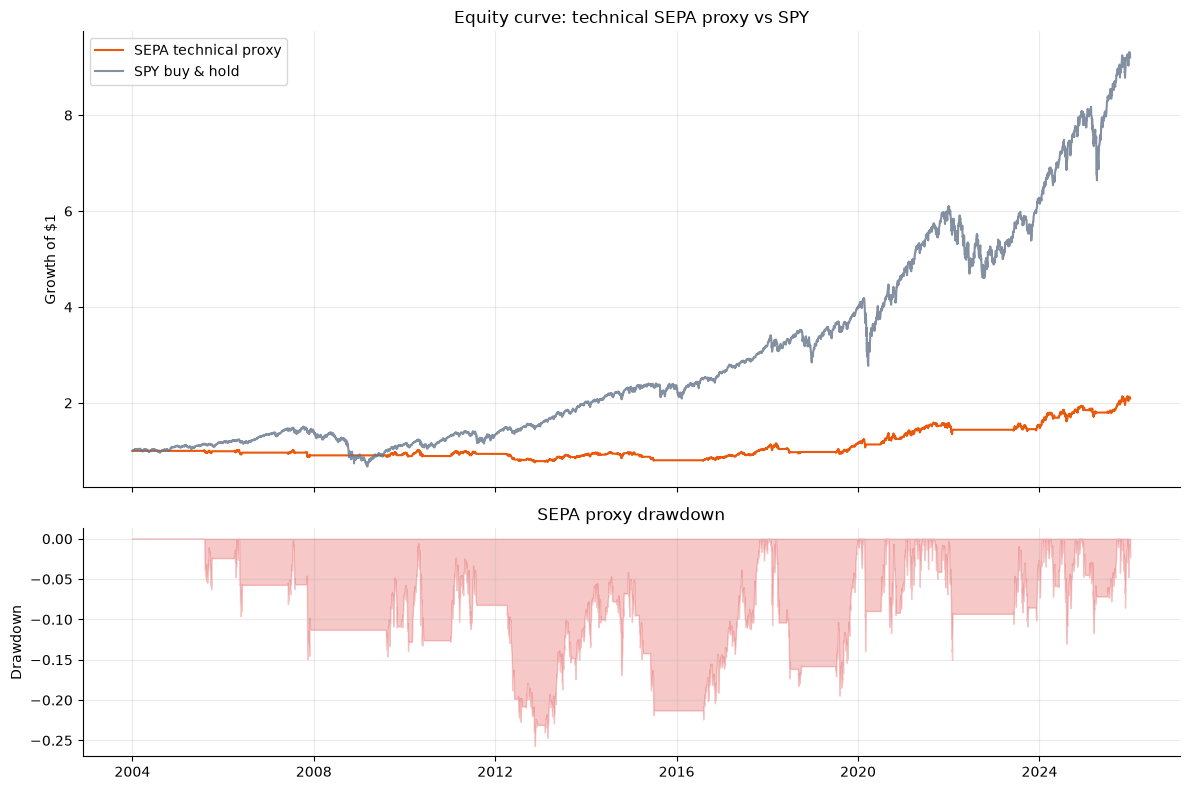

In [5]:

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
axes[0].plot(portfolio.frame.index, portfolio.frame.equity / portfolio.frame.equity.iloc[0], label="SEPA technical proxy", color="#EA580C")
axes[0].plot(spy_hold.frame.index, spy_hold.frame.equity / spy_hold.frame.equity.iloc[0], label="SPY buy & hold", color="#64748B", alpha=0.8)
axes[0].set_title("Equity curve: technical SEPA proxy vs SPY")
axes[0].set_ylabel("Growth of $1")
axes[0].legend()
axes[1].fill_between(portfolio.frame.index, portfolio.frame.drawdown, 0, color="#DC2626", alpha=0.25)
axes[1].set_title("SEPA proxy drawdown")
axes[1].set_ylabel("Drawdown")
plt.tight_layout()


## 🧪 Robustness and implementation gap

The parameters are tested around the public thresholds. They are ranked on validation only, while the original 75% / 130% rule is reported on the untouched test period.


In [6]:

grid_rows = []
for high_proximity, low_multiple in itertools.product([0.70, 0.75, 0.80], [1.20, 1.30, 1.40]):
    candidate_weights, _ = sepa_proxy_weights(close, high_proximity, low_multiple)
    candidate = run_portfolio_backtest(close, candidate_weights, transaction_cost_bps=10.0, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    validation = metrics_for_period(candidate, periods["validation"])
    test = metrics_for_period(candidate, periods["test"])
    grid_rows.append({"high_proximity": high_proximity, "low_multiple": low_multiple, "validation_sharpe": validation["sharpe_ratio"], "validation_return": validation["annualized_return"], "test_sharpe": test["sharpe_ratio"], "test_return": test["annualized_return"], "test_drawdown": test["max_drawdown"]})
sensitivity = pd.DataFrame(grid_rows).sort_values("validation_sharpe", ascending=False)
display(sensitivity.style.format({"high_proximity": "{:.0%}", "low_multiple": "{:.2f}", "validation_sharpe": "{:.2f}", "validation_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_return": "{:.2%}", "test_drawdown": "{:.2%}"}))


,high_proximity,low_multiple,validation_sharpe,validation_return,test_sharpe,test_return,test_drawdown
2,70%,1.40,0.88,13.82%,0.50,6.85%,-19.87%
5,75%,1.40,0.88,13.82%,0.50,6.85%,-19.87%
8,80%,1.40,0.88,13.82%,0.50,6.85%,-19.87%
1,70%,1.30,0.86,12.89%,0.58,7.14%,-15.00%
4,75%,1.30,0.86,12.89%,0.58,7.14%,-15.00%
7,80%,1.30,0.86,12.89%,0.58,7.14%,-15.00%
0,70%,1.20,0.80,11.89%,0.55,6.49%,-14.60%
3,75%,1.20,0.80,11.89%,0.55,6.49%,-14.60%
6,80%,1.20,0.80,11.89%,0.55,6.49%,-14.60%


In [7]:

cost_rows = []
for cost_bps in [0, 10, 25, 50]:
    cost_result = run_portfolio_backtest(close, weights, transaction_cost_bps=cost_bps, benchmark_returns=close["SPY"].pct_change().fillna(0.0))
    metrics = metrics_for_period(cost_result, periods["test"])
    cost_rows.append({"transaction_cost_bps": cost_bps, "test_return": metrics["annualized_return"], "test_sharpe": metrics["sharpe_ratio"], "test_drawdown": metrics["max_drawdown"], "test_turnover": metrics["annualized_turnover"]})
display(pd.DataFrame(cost_rows).style.format({"test_return": "{:.2%}", "test_sharpe": "{:.2f}", "test_drawdown": "{:.2%}", "test_turnover": "{:.2f}"}))


,transaction_cost_bps,test_return,test_sharpe,test_drawdown,test_turnover
0,0,7.67%,0.62,-14.72%,4.92
1,10,7.14%,0.58,-15.00%,4.92
2,25,6.35%,0.52,-15.50%,4.92
3,50,5.05%,0.43,-16.32%,4.92


,IWM,QQQ,SMH,SPY,XLF,XLK
Date,,,,,,
2016,0.11,0.00,0.28,0.00,0.03,0.00
2017,0.11,0.14,0.35,0.00,0.24,0.16
2018,0.00,0.10,0.15,0.00,0.02,0.14
2019,0.00,0.09,0.17,0.03,0.03,0.17
2020,0.02,0.18,0.15,0.03,0.02,0.18
2021,0.13,0.16,0.20,0.15,0.11,0.17
2022,0.00,0.02,0.02,0.02,0.00,0.02
2023,0.00,0.14,0.14,0.00,0.00,0.14
2024,0.08,0.21,0.14,0.16,0.18,0.14


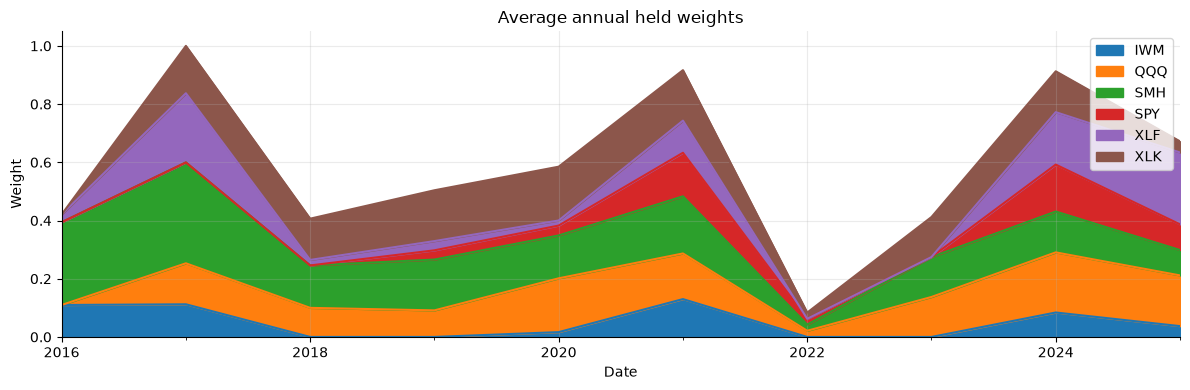

In [8]:

annual_allocation = portfolio.held_weights.groupby(portfolio.held_weights.index.to_period("Y")).mean().tail(10)
display(annual_allocation.round(2))
annual_allocation.plot.area(figsize=(12, 4), title="Average annual held weights")
plt.ylabel("Weight")
plt.tight_layout()


## ⚖️ What went well / what went wrong

### ✅ What went well

- The technical trend template is specific and easy for a beginner to inspect.
- Monthly ETF rotation reduces the need to trade every signal and keeps the portfolio transparent.
- The cross-sectional implementation shows how a single-stock checklist can become a portfolio rule.

### ⚠️ What went wrong or remains uncertain

- The most important SEPA inputs—earnings growth, sales growth, relative-strength ranks, sponsorship, catalysts, and VCP structure—are absent from this test.
- ETFs are not individual growth stocks, so this proxy may understate or distort the original strategy’s selection effect.
- The 52-week high/low filters can select assets after a long run-up and still suffer sharp reversals.
- A rule can look stable across nearby thresholds because the sample contains persistent trends; that does not prove robustness in a different universe.

**Bottom line:** the X post supplied a useful technical checklist, but the original strategy is fundamentally richer than this ETF proxy. The notebook demonstrates the gap instead of hiding it.
